# Traffic Accident Analysis

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:
# Load Dataset

df = pd.read_csv('/content/US_Accidents_March23_sampled_500k.csv')

In [ ]:
# Dataset Shape

df.shape

(500000, 46)

In [ ]:
# First Five Records

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                279623 non-null  float64
 8   End_Lng                279623 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            499999 non-null  object 
 11  Street                 499309 non-null  object 
 12  City                   499981 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

In [ ]:
# Column Names

df.columns.tolist()

['ID',
 'Source',
 'Severity',
 'Start_Time',
 'End_Time',
 'Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

In [ ]:
# Statistical Summary

df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,279623.000000,279623.000000,500000.000000,489534.000000,370983.000000,488870.000000,491072.000000,488709.000000,463013.000000,357384.000000
mean,2.212748,36.206421,-94.736583,36.273192,-95.776553,0.564317,61.646254,58.229028,64.834921,29.536621,9.091540,7.681347,0.008289
std,0.486661,5.071411,17.405761,5.265333,18.120211,1.774872,19.000133,22.352246,22.826158,1.008666,2.708083,5.431361,0.101865
min,1.000000,24.562117,-124.497420,24.570110,-124.497419,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.416823,-117.233047,33.474773,-117.778324,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.832147,-87.794365,36.192669,-88.039013,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.082443,-80.359601,40.181341,-80.252449,0.465000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.999569,-67.484130,48.998901,-67.484130,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000


In [ ]:
# Missing Values

missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
End_Lat,220377
End_Lng,220377
Precipitation(in),142616
Wind_Chill(F),129017
Wind_Speed(mph),36987
Visibility(mi),11291
Wind_Direction,11197
Humidity(%),11130
Weather_Condition,11101
Temperature(F),10466


In [ ]:
# Missing Values Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

,0
End_Lat,44.0754
End_Lng,44.0754
Precipitation(in),28.5232
Wind_Chill(F),25.8034
Wind_Speed(mph),7.3974
Visibility(mi),2.2582
Wind_Direction,2.2394
Humidity(%),2.2260
Weather_Condition,2.2202
Temperature(F),2.0932


## Observation

Key findings:

- End_Lat and End_Lng contain more than 40% missing values.
- Wind_Chill(F) contains a large number of missing values.
- Precipitation(in) also contains substantial missing values.

These columns will be removed because they are unlikely to contribute significantly to the analysis.

In [ ]:
# Remove High Missing Value Columns

df.drop(
    columns=[
        "End_Lat",
        "End_Lng",
        "Wind_Chill(F)",
        "Precipitation(in)"
    ],
    inplace=True
)

In [ ]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [ ]:
# Fill Missing Numerical Values

numeric_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)"
]

for col in numeric_cols:

    df[col].fillna(
        df[col].median(),
        inplace=True
    )

In [ ]:
# Fill Missing Categorical Values

categorical_cols = [
    "Weather_Condition",
    "Wind_Direction",
    "Sunrise_Sunset"
]

for col in categorical_cols:

    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

In [ ]:
# Date Conversion

df["Start_Time"] = pd.to_datetime(df["Start_Time"],format='mixed')

df["End_Time"] = pd.to_datetime(df["End_Time"],format='mixed')

In [ ]:
# Accident Duration

df["Duration_Minutes"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60

In [ ]:
# Hour Feature

df["Hour"] = (df["Start_Time"].dt.hour)

In [ ]:
# Day Feature

df["Day"] = (df["Start_Time"].dt.day_name())

In [ ]:
# Month Feature

df["Month"] = (df["Start_Time"].dt.month_name())


In [ ]:
# Check New Features

df[["Duration_Minutes","Hour","Day","Month"]].head()

,Duration_Minutes,Hour,Day,Month
0,45.033333,10,Wednesday,June
1,139.650000,23,Saturday,December
2,129.750000,13,Saturday,August
3,120.316667,17,Monday,February
4,147.150000,1,Friday,December


In [ ]:
# Severity Count

df["Severity"].value_counts()

,count
Severity,
2,398142
3,84520
4,13064
1,4274


In [ ]:
# Severity Percentage

severity_percent = (
    df["Severity"]
    .value_counts(normalize=True)
    * 100
).round(2)

severity_percent

,proportion
Severity,
2,79.63
3,16.90
4,2.61
1,0.85


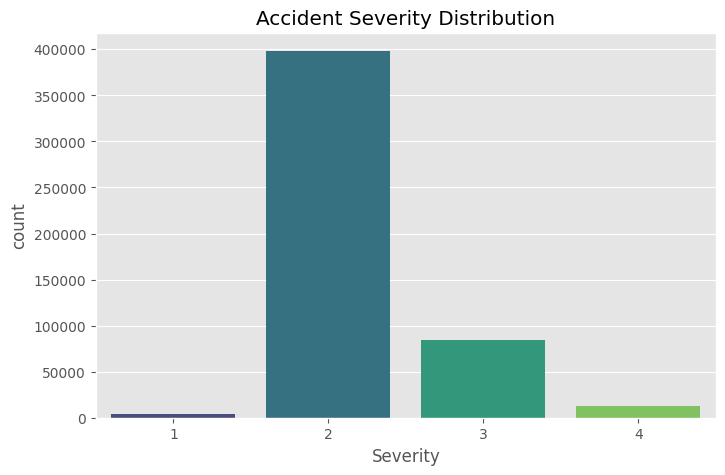

In [ ]:
# Severity Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x="Severity",
    data=df,
    palette="viridis"
)

plt.title(
    "Accident Severity Distribution"
)

plt.show()

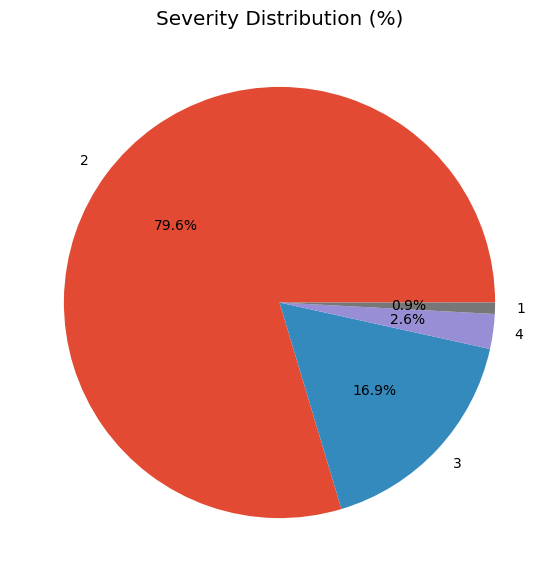

In [ ]:
# Severity Percentage Pie Chart

severity_percent.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title(
    "Severity Distribution (%)"
)

plt.ylabel("")

plt.show()


Nearly 80% of accidents belong to Severity Level 2.

This indicates that moderate accidents dominate
the accident landscape.

Highly severe accidents represent
a relatively small proportion of total incidents.

The severity distribution is highly imbalanced.

# Rush Hour Analysis

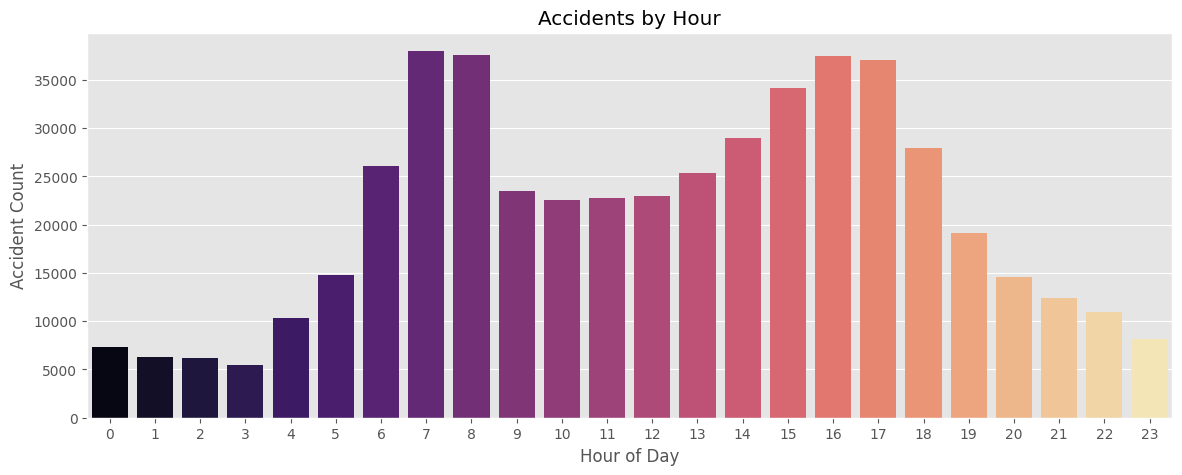

In [ ]:
# Accidents by Hour

plt.figure(figsize=(14,5))

sns.countplot(
    x="Hour",
    data=df,
    palette="magma"
)

plt.title(
    "Accidents by Hour"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Accident Count"
)

plt.show()

In [ ]:
# Hourly Accident Count Table

hourly_accidents = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

hourly_accidents

,count
Hour,
0,7374
1,6265
2,6151
3,5425
4,10380
5,14754
6,26094
7,37988
8,37626


In [ ]:
# Top Accident Hours

hourly_accidents.sort_values(
    ascending=False
).head(10)

,count
Hour,
7,37988
8,37626
16,37424
17,37099
15,34126
14,28959
18,27929
6,26094
13,25400


Accident frequency peaks during:

• Morning Rush Hour (7 AM – 8 AM)

• Evening Rush Hour (4 PM – 5 PM)

These periods correspond to heavy commuter traffic.

Traffic congestion appears to be a major contributor
to accident occurrence.

In [ ]:
# Average Severity by Hour

hour_severity = (
    df.groupby("Hour")
    ["Severity"]
    .mean()
    .reset_index()
)

hour_severity.head()

,Hour,Severity
0,0,2.217521
1,1,2.181963
2,2,2.206308
3,3,2.222673
4,4,2.234875


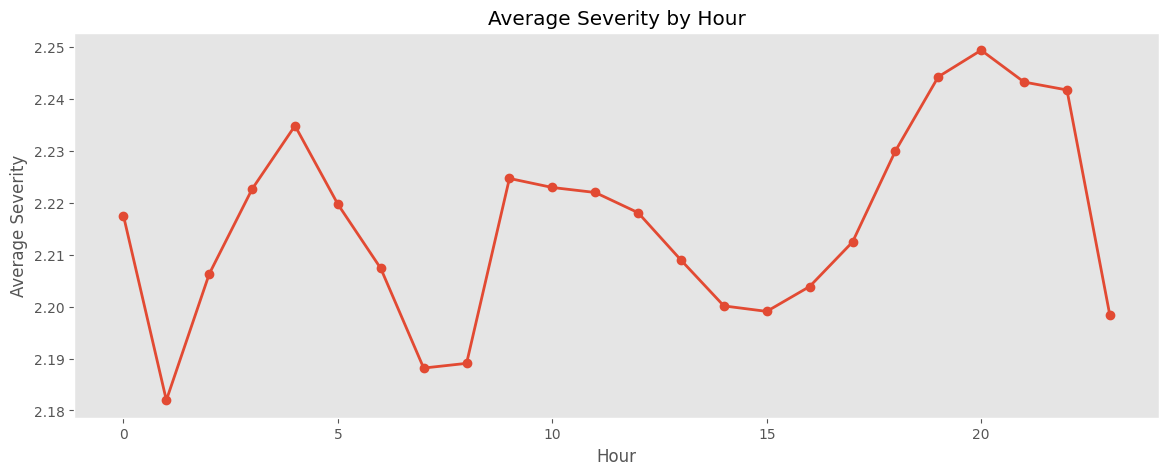

In [ ]:
# Severity Trend by Hour

plt.figure(figsize=(14,5))

plt.plot(
    hour_severity["Hour"],
    hour_severity["Severity"],
    marker="o",
    linewidth=2
)

plt.title(
    "Average Severity by Hour"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Average Severity"
)

plt.grid()

plt.show()

While rush-hour periods generate
the highest accident volume,

the severity trend helps determine
whether specific hours produce
more severe accidents.

This provides deeper insight than
accident counts alone.

# Junction Severity Analysis

Road junctions are among the most complex
traffic environments.

This section investigates whether accidents
occurring near junctions are more severe.

In [ ]:
# Junction Severity Table

junction_severity = (
    df.groupby("Junction")
    ["Severity"]
    .mean()
    .reset_index()
)

junction_severity

,Junction,Severity
0,False,2.205707
1,True,2.300835


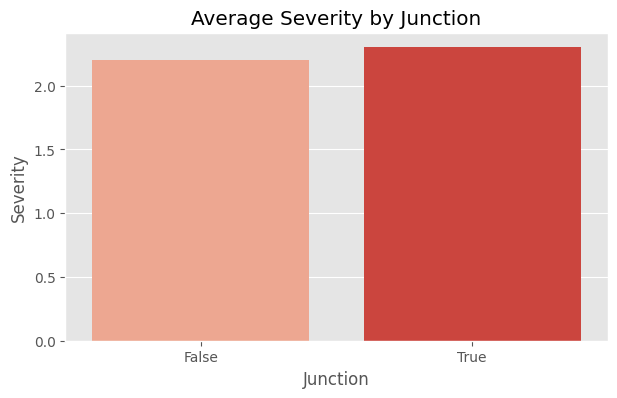

In [ ]:
# Junction Severity Plot

plt.figure(figsize=(7,4))

sns.barplot(
    x="Junction",
    y="Severity",
    data=junction_severity,
    palette="Reds"
)

plt.title(
    "Average Severity by Junction"
)

plt.show()

In [ ]:
# Junction Accident Count

df["Junction"].value_counts()

,count
Junction,
False,462993
True,37007


Accidents occurring near junctions
show higher average severity.

Junctions involve:

• Multiple vehicle movements

• Crossing traffic

• Lane changes

These factors increase driving complexity
and accident risk.

This finding suggests that junctions should
be prioritized for road safety improvements.

# Road Infrastructure Risk Analysis

In [ ]:
road_features = [
    "Junction",
    "Traffic_Signal",
    "Crossing",
    "Stop"
]

for feature in road_features:

    print("\n", feature)

    print(
        df.groupby(feature)
        ["Severity"]
        .mean()
    )


 Junction
Junction
False    2.205707
True     2.300835
Name: Severity, dtype: float64

 Traffic_Signal
Traffic_Signal
False    2.234069
True     2.090079
Name: Severity, dtype: float64

 Crossing
Crossing
False    2.231501
True     2.064814
Name: Severity, dtype: float64

 Stop
Stop
False    2.216703
True     2.076086
Name: Severity, dtype: float64


In [ ]:
# Road Infrastructure Severity Comparison

infrastructure_risk = pd.DataFrame({
    "Feature": [
        "Junction",
        "Traffic Signal",
        "Crossing",
        "Stop"
    ],
    "Average_Severity": [
        df.groupby("Junction")["Severity"].mean()[True],
        df.groupby("Traffic_Signal")["Severity"].mean()[True],
        df.groupby("Crossing")["Severity"].mean()[True],
        df.groupby("Stop")["Severity"].mean()[True]
    ]
})

infrastructure_risk

,Feature,Average_Severity
0,Junction,2.300835
1,Traffic Signal,2.090079
2,Crossing,2.064814
3,Stop,2.076086


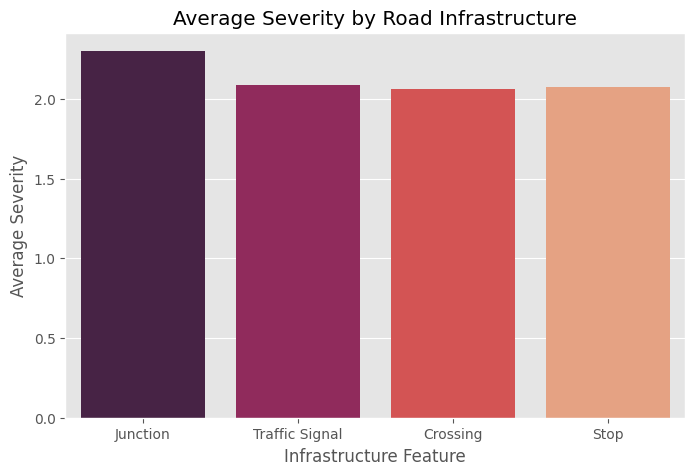

In [ ]:
# Infrastructure Risk Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x="Feature",
    y="Average_Severity",
    data=infrastructure_risk,
    palette="rocket"
)

plt.title(
    "Average Severity by Road Infrastructure"
)

plt.xlabel(
    "Infrastructure Feature"
)

plt.ylabel(
    "Average Severity"
)

plt.show()

Among all analyzed road infrastructure features,
junction-related accidents exhibit the highest
average severity.

Traffic signals, crossings, and stop signs
are associated with lower accident severity,
suggesting that traffic control infrastructure
may help reduce accident impact.

Junctions remain the most critical
road safety risk factor identified
in this analysis.

# State Risk Index

Accident count alone does not accurately represent road safety risk.

A state may have high accident volume but low severity,
or lower accident volume but higher severity.

To overcome this limitation, a custom Risk Index is created.

### Risk Index Formula

Risk Index = Accident Count × Average Severity

This metric combines both accident frequency
and accident impact.

In [ ]:
# State Accident Count

state_accidents = (
    df.groupby("State")
    .size()
    .reset_index(
        name="Accident_Count"
    )
)

state_accidents.head()

,State,Accident_Count
0,AL,6585
1,AR,1483
2,AZ,11150
3,CA,113274
4,CO,5924


In [ ]:
# State Average Severity

state_severity = (
    df.groupby("State")
    ["Severity"]
    .mean()
    .reset_index(
        name="Average_Severity"
    )
)

state_severity.head()

,State,Average_Severity
0,AL,2.243432
1,AR,2.285907
2,AZ,2.122332
3,CA,2.166075
4,CO,2.435179


In [ ]:
# State Risk Index

state_risk = pd.merge(
    state_accidents,
    state_severity,
    on="State"
)

state_risk["Risk_Index"] = (
    state_risk["Accident_Count"]
    *
    state_risk["Average_Severity"]
)

state_risk.head()

,State,Accident_Count,Average_Severity,Risk_Index
0,AL,6585,2.243432,14773.0
1,AR,1483,2.285907,3390.0
2,AZ,11150,2.122332,23664.0
3,CA,113274,2.166075,245360.0
4,CO,5924,2.435179,14426.0


In [ ]:
# Top Risky States

top_risky_states = (
    state_risk
    .sort_values(
        by="Risk_Index",
        ascending=False
    )
    .head(10)
)

top_risky_states

,State,Accident_Count,Average_Severity,Risk_Index
3,CA,113274,2.166075,245360.0
8,FL,56710,2.138882,121296.0
41,TX,37355,2.223638,83064.0
38,SC,24737,2.111170,52224.0
32,NY,22594,2.259538,51052.0
25,NC,21750,2.132920,46391.0
43,VA,19515,2.277530,44446.0
36,PA,19351,2.203762,42645.0
9,GA,11079,2.500045,27698.0
21,MN,12333,2.166545,26720.0


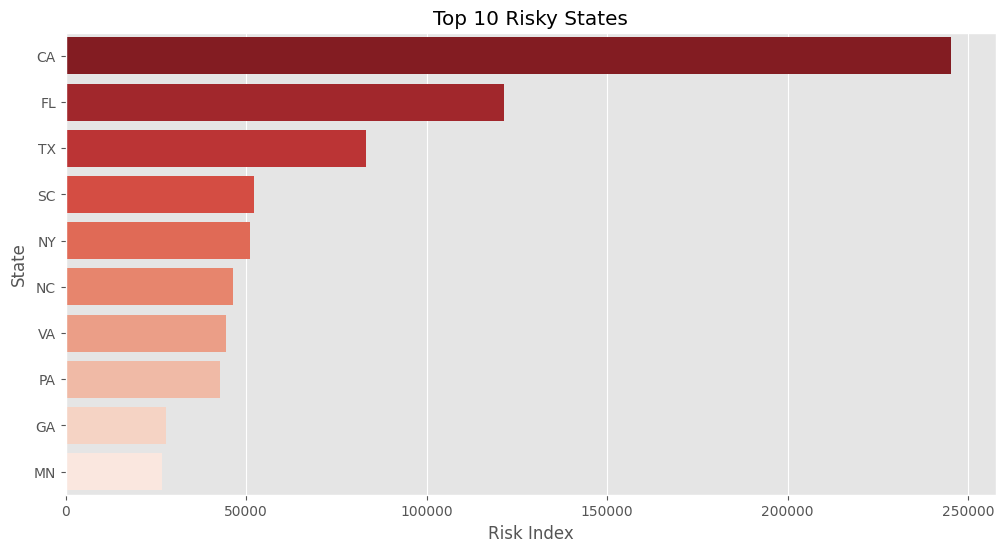

In [ ]:
# Dangerous States Graph

plt.figure(figsize=(12,6))

sns.barplot(
    x="Risk_Index",
    y="State",
    data=top_risky_states,
    palette="Reds_r"
)

plt.title(
    "Top 10 Risky States"
)

plt.xlabel(
    "Risk Index"
)

plt.ylabel(
    "State"
)

plt.show()

California, Florida, and Texas exhibit
the highest overall road safety risk.

The Risk Index combines accident volume
and accident severity,
providing a more comprehensive measure
than accident count alone.

These states account for a substantial share
of accident-related risk and should be prioritized
for road safety interventions.

# City Risk Index

Cities often experience very different
traffic conditions than states.

This section identifies the most critical
urban accident zones.

In [ ]:
# City Risk Index

city_risk = (
    df.groupby("City")
    .agg({
        "Severity":"mean",
        "ID":"count"
    })
    .reset_index()
)

city_risk.columns = [
    "City",
    "Average_Severity",
    "Accident_Count"
]

city_risk["Risk_Index"] = (
    city_risk["Average_Severity"]
    *
    city_risk["Accident_Count"]
)

city_risk.head()

,City,Average_Severity,Accident_Count,Risk_Index
0,Aaronsburg,2.000000,1,2.0
1,Abbeville,2.000000,39,78.0
2,Abbotsford,2.666667,3,8.0
3,Abbott,2.500000,2,5.0
4,Abbottstown,2.666667,9,24.0


In [ ]:
# Top Risky Cities

top_risky_cities = (
    city_risk
    .sort_values(
        by="Risk_Index",
        ascending=False
    )
    .head(10)
)

top_risky_cities


,City,Average_Severity,Accident_Count,Risk_Index
5316,Miami,2.105840,12141,25567.0
3881,Houston,2.185387,11031,24107.0
4803,Los Angeles,2.230605,10299,22973.0
1985,Dallas,2.258217,8245,18619.0
1425,Charlotte,2.043101,8979,18345.0
6306,Orlando,2.061847,6985,14402.0
341,Austin,2.085979,6269,13077.0
6948,Raleigh,2.092022,5553,11617.0
315,Atlanta,2.539996,4463,11336.0
5753,Nashville,2.148433,4689,10074.0


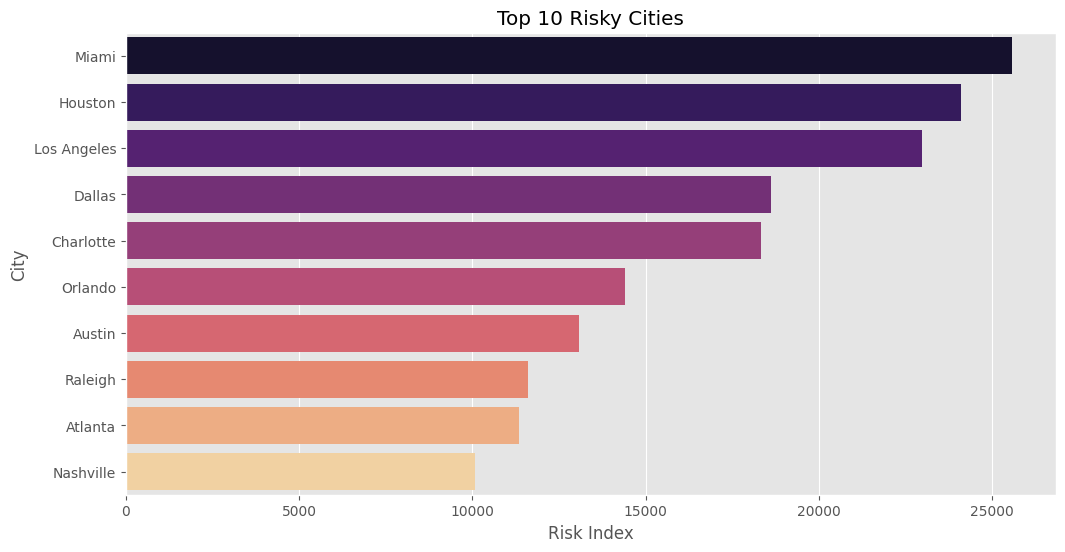

In [ ]:
# Dangerous Cities Graph

plt.figure(figsize=(12,6))

sns.barplot(
    x="Risk_Index",
    y="City",
    data=top_risky_cities,
    palette="magma"
)

plt.title(
    "Top 10 Risky Cities"
)

plt.xlabel(
    "Risk Index"
)

plt.ylabel(
    "City"
)

plt.show()

Miami, Houston, and Los Angeles emerge
as the highest-risk cities in the dataset.

These cities experience both:

- High accident frequency
- Significant accident severity

Urban traffic density and transportation complexity
are likely contributors to elevated risk levels.

# Weather Analysis

In [ ]:
weather_top = (
    df["Weather_Condition"]
    .value_counts()
    .head(10)
)

weather_top

,count
Weather_Condition,
Fair,177154
Mostly Cloudy,65398
Cloudy,53107
Clear,52379
Partly Cloudy,45125
Overcast,24901
Light Rain,22718
Scattered Clouds,13030
Light Snow,8233


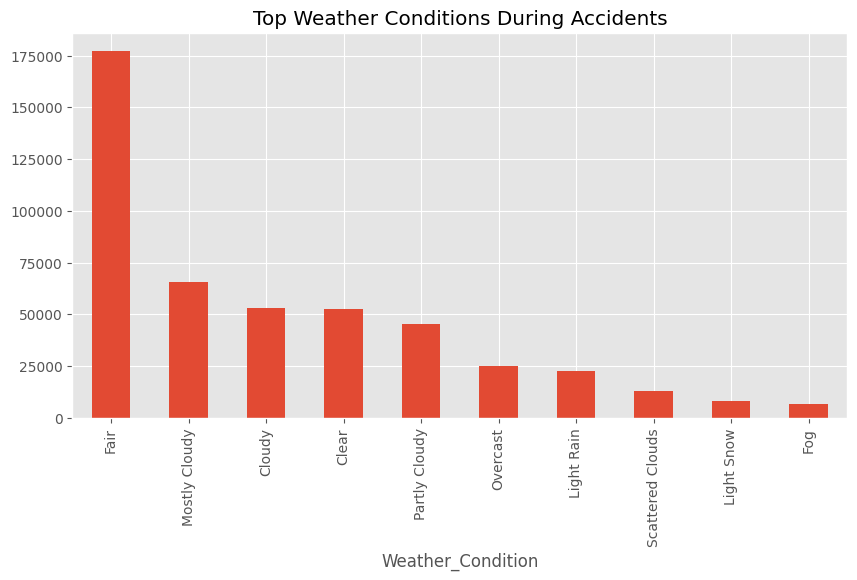

In [ ]:
plt.figure(figsize=(10,5))

weather_top.plot(
    kind="bar"
)

plt.title(
    "Top Weather Conditions During Accidents"
)

plt.show()

Most accidents occurred during:

• Fair

• Mostly Cloudy

• Clear

weather conditions.

These conditions represent the most common
driving environments and therefore account
for the highest accident exposure.

# Duration Impact Analysis

Accident severity alone does not capture
the operational impact of an accident.

Duration analysis helps understand
how long accidents affect traffic flow.

In [ ]:
# Duration Statistics

df["Duration_Minutes"].describe()

,Duration_Minutes
count,5.000000e+05
mean,4.219465e+02
std,1.320643e+04
min,2.500000e+00
25%,3.150000e+01
50%,7.486667e+01
75%,1.252333e+02
max,2.236406e+06


## Observation

The duration feature contains extreme outliers.

The maximum recorded duration exceeds
2 million minutes, which is unrealistic
for traffic accident events.

These outliers distort the duration distribution
and must be removed before analysis.

In [ ]:
# Remove Duration Outliers

duration_df = df[
    df["Duration_Minutes"] <= 1440 # 1440 minutes = 24 hours
]

In [ ]:
duration_df["Duration_Minutes"].describe()

,Duration_Minutes
count,497801.000000
mean,108.174187
std,123.748994
min,2.500000
25%,31.283333
50%,74.766667
75%,124.633333
max,1440.000000


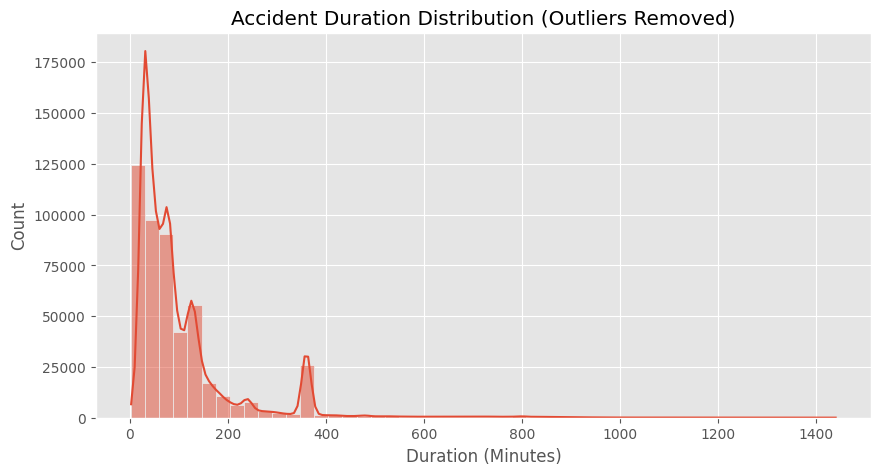

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    duration_df["Duration_Minutes"],
    bins=50,
    kde=True
)

plt.title(
    "Accident Duration Distribution (Outliers Removed)"
)

plt.xlabel(
    "Duration (Minutes)"
)

plt.show()

In [ ]:
# Duration by Severity

duration_analysis = (
    duration_df
    .groupby("Severity")
    ["Duration_Minutes"]
    .median()
    .reset_index()
)

duration_analysis

,Severity,Duration_Minutes
0,1,44.766667
1,2,77.433333
2,3,44.400000
3,4,127.550000


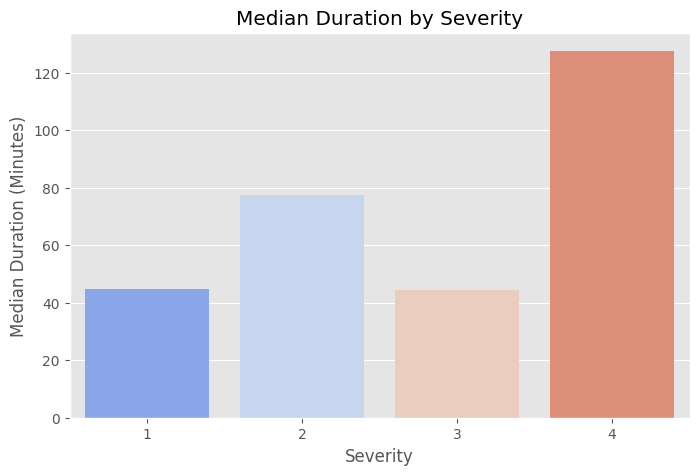

In [ ]:
# Duration Impact Plot

plt.figure(figsize=(8,5))

sns.barplot(
    x="Severity",
    y="Duration_Minutes",
    data=duration_analysis,
    palette="coolwarm"
)

plt.title(
    "Median Duration by Severity"
)

plt.xlabel(
    "Severity"
)

plt.ylabel(
    "Median Duration (Minutes)"
)

plt.show()

Severity Level 4 accidents require
substantially longer clearance times.

These incidents create:

- Greater traffic disruption
- Increased emergency response demand
- Higher operational impact

Accident duration is therefore an important
indicator of overall accident impact.

# Accident Hotspot Analysis

Accident frequency is not distributed uniformly.

Certain geographic regions experience
significantly higher accident concentrations.

This section identifies accident hotspots
using geographic coordinates.

In [ ]:
# Create Sample for Heatmap

sample = df.sample(
    10000,
    random_state=42
)

sample.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,...,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration_Minutes,Hour,Day,Month
104241,A-7307599,Source1,3,2019-12-10 10:36:07,2019-12-10 11:05:22,39.115330,-108.544750,0.000,At Horizon Drive/Exit 31 - Accident.,I-70 E,...,False,False,Day,Day,Day,Day,29.250000,10,Tuesday,December
199676,A-1992556,Source2,2,2019-07-29 07:34:01,2019-07-29 09:05:08,35.115662,-81.069710,0.000,Accident on SC-49 both ways at Forest Oaks Dr.,Charlotte Hwy,...,False,False,Day,Day,Day,Day,91.116667,7,Monday,July
140199,A-5306504,Source1,4,2022-11-07 22:45:00,2022-11-08 03:15:00,30.238410,-97.738505,0.953,Incident on I-35 SB near US-290 Road closed. T...,I-35 S,...,False,False,Night,Night,Night,Night,270.000000,22,Monday,November
132814,A-2683723,Source2,2,2018-07-03 13:15:46,2018-07-03 13:45:15,40.153828,-75.419403,0.000,Accident on Eagleville Rd at Visitation Rd.,Eagleville Rd,...,False,False,Day,Day,Day,Day,29.483333,13,Tuesday,July
408697,A-6573560,Source1,2,2021-02-22 17:47:00,2021-02-22 19:05:25,38.114959,-77.517769,0.868,Incident on I-95 NB near MM 118 Expect delays.,I-95 N,...,False,False,Day,Day,Day,Day,78.416667,17,Monday,February


In [ ]:
# Create Base Map

accident_map = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4
)

accident_map

In [ ]:
# Add Heatmap Layer

HeatMap(
    sample[
        [
            "Start_Lat",
            "Start_Lng"
        ]
    ]
).add_to(
    accident_map
)

accident_map

Accident hotspots are concentrated in major
metropolitan regions and transportation corridors.

High traffic density,
urban mobility,
and road network complexity
are likely contributors to hotspot formation.

These regions should receive priority attention
for road safety monitoring and infrastructure improvements.

# Executive Dashboard

This section summarizes the most important findings
from the entire analysis.

The goal is to convert analytical findings
into actionable business insights.

In [ ]:
# Total Accidents

total_accidents = len(df)

print(
    "Total Accidents:",
    total_accidents
)

Total Accidents: 500000


In [ ]:
# Average Severity

avg_severity = round(
    df["Severity"].mean(),
    2
)

print(
    "Average Severity:",
    avg_severity
)

Average Severity: 2.21


In [ ]:
# States Covered

total_states = (
    df["State"]
    .nunique()
)

print(
    "States Covered:",
    total_states
)

States Covered: 49


In [ ]:
# Cities Covered

total_cities = (
    df["City"]
    .nunique()
)

print(
    "Cities Covered:",
    total_cities
)

Cities Covered: 9488


In [ ]:
# Top Risky State

top_risky_states.head(1)

,State,Accident_Count,Average_Severity,Risk_Index
3,CA,113274,2.166075,245360.0


In [ ]:
# Top Risky City

top_risky_cities.head(1)

,City,Average_Severity,Accident_Count,Risk_Index
5316,Miami,2.10584,12141,25567.0


### Key Findings

1. Nearly 80% of accidents belong to Severity Level 2.

2. Accident frequency peaks during morning and evening rush hours.

3. Junction-related accidents exhibit the highest average severity among analyzed road infrastructure features.

4. Traffic signals, crossings, and stop signs are associated with lower accident severity, suggesting a positive safety impact.

5. California, Florida, and Texas exhibit the highest overall road safety risk.

6. Miami, Houston, and Los Angeles emerge as the highest-risk cities.

7. Severity Level 4 accidents require significantly longer clearance times and create greater traffic disruption.

8. Most accidents occur during Fair, Mostly Cloudy, and Clear weather conditions, reflecting the most common driving environments.

9. Accident hotspots are concentrated in major urban regions and transportation corridors.

10. Risk Index provides a more comprehensive measure than accident count alone for identifying high-risk locations.

# Business Recommendations

### Recommendation 1

Increase traffic monitoring and traffic management
during peak rush-hour periods to reduce congestion-related accidents.

---

### Recommendation 2

Prioritize safety improvements at major junctions,
including better signal timing, lane markings,
and intersection design.

---

### Recommendation 3

Expand and maintain traffic control infrastructure
such as traffic signals, crossings, and stop signs,
as these features are associated with lower accident severity.

---

### Recommendation 4

Prioritize road safety investments in high-risk states:

- California
- Florida
- Texas

---

### Recommendation 5

Implement targeted accident prevention programs
in high-risk cities:

- Miami
- Houston
- Los Angeles

---

### Recommendation 6

Improve incident response and clearance processes
for high-severity accidents to minimize traffic disruption.

---

### Recommendation 7

Deploy additional monitoring and enforcement resources
in identified accident hotspot regions and major transportation corridors.

---

### Recommendation 8

Use Risk Index metrics for data-driven transportation planning,
resource allocation, and road safety decision-making.

# Final Conclusion

This project analyzed more than 500,000 accident records
to identify patterns related to:

- Accident Severity
- Time of Day
- Weather Conditions
- Road Infrastructure
- Geographic Risk

The analysis revealed that:

- Nearly 80% of accidents belong to Severity Level 2.
- Accident frequency peaks during morning and evening rush hours.
- Junction-related accidents exhibit the highest severity among analyzed road infrastructure features.
- Traffic signals, crossings, and stop signs are associated with lower accident severity.
- California, Florida, and Texas exhibit the highest overall road safety risk.
- Miami, Houston, and Los Angeles emerge as the highest-risk cities.
- Severity Level 4 accidents require significantly longer clearance times.
- Most accidents occur during Fair, Mostly Cloudy, and Clear weather conditions.
- Accident hotspots are concentrated in major urban regions and transportation corridors.

A custom Risk Index framework was developed
to combine accident frequency and accident severity
into a single decision-making metric.

The findings provide actionable insights that can help
transportation authorities:

- Prioritize road safety investments
- Improve junction and infrastructure safety
- Optimize traffic management strategies
- Reduce accident-related disruptions
- Allocate resources more effectively

This project demonstrates how data analytics can transform
large-scale accident records into actionable road safety intelligence,
supporting data-driven transportation planning and decision-making.